The below code is for a 3D Plot

Found 424 snapshots:
Rendering 1/424: timestep 0


/tmp/ipykernel_307088/734730345.py:88: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame_path))


Rendering 2/424: timestep 500
Rendering 3/424: timestep 1000
Rendering 4/424: timestep 1500
Rendering 5/424: timestep 2000
Rendering 6/424: timestep 2500
Rendering 7/424: timestep 3000
Rendering 8/424: timestep 3500
Rendering 9/424: timestep 4000
Rendering 10/424: timestep 4500
Rendering 11/424: timestep 5000
Rendering 12/424: timestep 5500
Rendering 13/424: timestep 6000
Rendering 14/424: timestep 6500
Rendering 15/424: timestep 7000
Rendering 16/424: timestep 7500
Rendering 17/424: timestep 8000
Rendering 18/424: timestep 8500
Rendering 19/424: timestep 9000
Rendering 20/424: timestep 9500
Rendering 21/424: timestep 10000
Rendering 22/424: timestep 10500
Rendering 23/424: timestep 11000
Rendering 24/424: timestep 11500
Rendering 25/424: timestep 12000
Rendering 26/424: timestep 12500
Rendering 27/424: timestep 13000
Rendering 28/424: timestep 13500
Rendering 29/424: timestep 14000
Rendering 30/424: timestep 14500
Rendering 31/424: timestep 15000
Rendering 32/424: timestep 15500
Rende

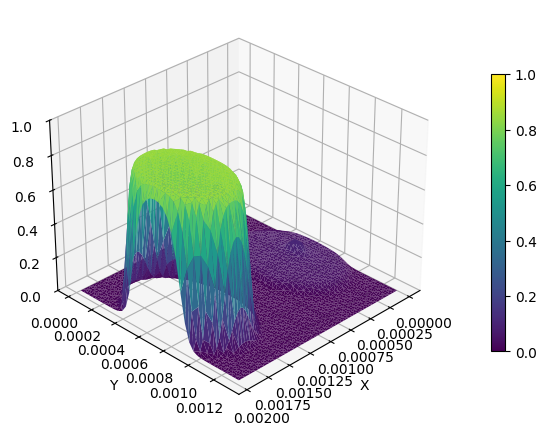

In [5]:
import mfem.ser as mfem
import numpy as np
import matplotlib.pyplot as plt
import imageio
import glob, os
from matplotlib.colors import Normalize


# --- USER SETTINGS ---
result_dir = "../outputs/Results/20251107_143844__nsteps=1000__mesh=Mesh_40x60x3_3D_disk_full"
mesh_file = os.path.join(result_dir, "pmesh_00000")
pattern = os.path.join(result_dir, "CnP_[0-9]*")  # skip gif output
output_gif = os.path.join(result_dir, "CnP_animation.gif")

# --- Load mesh once ---
mesh = mfem.Mesh()
mesh.Load(mesh_file)

# Vertex coordinates
vertices = mesh.GetVertexArray()
ar = np.array(vertices)
X, Y = ar[:, 0], ar[:, 1]

# --- Gather snapshot files ---
files = sorted(glob.glob(pattern))

# Sort numerically by timestep, not lexicographically
def get_timestep(fname):
    try:
        return int(os.path.basename(fname).split("_")[-1])
    except ValueError:
        return -1

files = sorted(files, key=get_timestep)
files = [f for f in files if os.path.basename(f).split("_")[-1].isdigit()]

print(f"Found {len(files)} snapshots:")
# for f in files:
#     print("  ", os.path.basename(f))

# --- Setup figure once ---
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
# ax.set_title("Electrolyte Potential (phE)")
ax.view_init(elev=30, azim=45)

norm = Normalize(vmin=0.0, vmax=1.0)
levels = np.linspace(0, 1, 100) 

# Initialize dummy colorbar
dummy = ax.plot_trisurf(X, Y, np.zeros_like(X), cmap='viridis', norm=norm)
cbar = fig.colorbar(dummy, ax=ax, shrink=0.6, pad=0.1)
dummy.remove()

# --- Create GIF writer ---
with imageio.get_writer(output_gif, mode='I', fps=5) as writer:
    for i, fname in enumerate(files):
        step_str = os.path.basename(fname).split("_")[-1]
        timestep = int(step_str)
        print(f"Rendering {i+1}/{len(files)}: timestep {timestep}")

        # Load grid function
        x = mfem.GridFunction(mesh, fname)
        Z = x.GetDataArray()

        # Auto-compute color scale for this frame
        # zmin, zmax = np.min(Z), np.max(Z)

        Z = np.clip(Z, 0.0, 1.0)

        zmin, zmax = np.min(Z), np.max(Z)

        # Redraw surface and colorbar
        ax.clear()
        surf = ax.plot_trisurf(X, Y, Z, cmap='viridis', norm=norm)
        ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
        # ax.set_title(f"Electrolyte Potential (phE) — timestep {timestep}")
        ax.set_zlim(0.0, 1.0)
        # Update colorbar each frame
        cbar.ax.clear()
        fig.colorbar(surf, cax=cbar.ax)
        # cbar.ax.set_ylabel("Potential")

        # Save frame
        frame_path = "temp_frame.png"
        plt.savefig(frame_path, dpi=100, bbox_inches='tight')
        writer.append_data(imageio.imread(frame_path))

os.remove("temp_frame.png")
print(f"✅ Animation saved to: {output_gif}")

The below code is used for the 2D Contour Plot

Found 424 snapshots:
Rendering 1/424: timestep 0


/tmp/ipykernel_307088/1989912452.py:76: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(frame_path))


Rendering 2/424: timestep 500
Rendering 3/424: timestep 1000
Rendering 4/424: timestep 1500
Rendering 5/424: timestep 2000
Rendering 6/424: timestep 2500
Rendering 7/424: timestep 3000
Rendering 8/424: timestep 3500
Rendering 9/424: timestep 4000
Rendering 10/424: timestep 4500
Rendering 11/424: timestep 5000
Rendering 12/424: timestep 5500
Rendering 13/424: timestep 6000
Rendering 14/424: timestep 6500
Rendering 15/424: timestep 7000
Rendering 16/424: timestep 7500
Rendering 17/424: timestep 8000
Rendering 18/424: timestep 8500
Rendering 19/424: timestep 9000
Rendering 20/424: timestep 9500
Rendering 21/424: timestep 10000
Rendering 22/424: timestep 10500
Rendering 23/424: timestep 11000
Rendering 24/424: timestep 11500
Rendering 25/424: timestep 12000
Rendering 26/424: timestep 12500
Rendering 27/424: timestep 13000
Rendering 28/424: timestep 13500
Rendering 29/424: timestep 14000
Rendering 30/424: timestep 14500
Rendering 31/424: timestep 15000
Rendering 32/424: timestep 15500
Rende

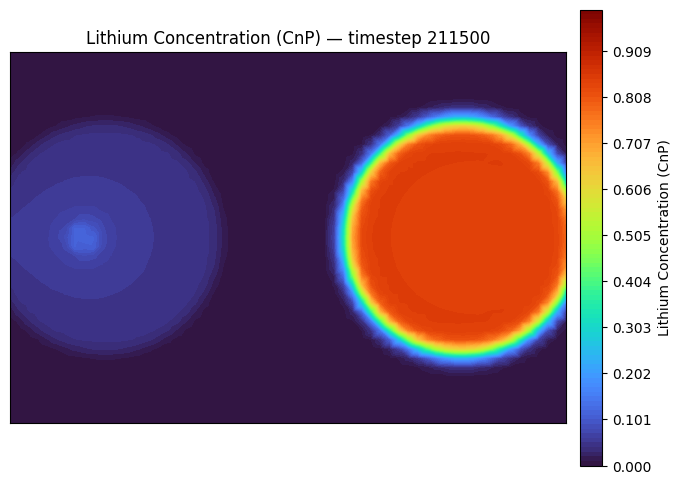

In [6]:
import mfem.ser as mfem
import numpy as np
import matplotlib.pyplot as plt
import imageio
import glob, os
from matplotlib.colors import Normalize

# --- USER SETTINGS ---
result_dir = "../outputs/Results/20251107_143844__nsteps=1000__mesh=Mesh_40x60x3_3D_disk_full"
mesh_file = os.path.join(result_dir, "pmesh_00000")
pattern = os.path.join(result_dir, "CnP_[0-9]*")
output_gif = os.path.join(result_dir, "CnP_contour_animation.gif")

# --- Load mesh once ---
mesh = mfem.Mesh()
mesh.Load(mesh_file)

# Get vertex coordinates
vertices = mesh.GetVertexArray()
ar = np.array(vertices)
X, Y = ar[:, 0], ar[:, 1]

# --- Gather snapshot files ---
files = sorted(glob.glob(pattern))

# Sort numerically by timestep, not lexicographically
def get_timestep(fname):
    try:
        return int(os.path.basename(fname).split("_")[-1])
    except ValueError:
        return -1

files = sorted(files, key=get_timestep)
files = [f for f in files if os.path.basename(f).split("_")[-1].isdigit()]

print(f"Found {len(files)} snapshots:")

# --- Setup figure ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_aspect('equal', adjustable='box')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

# ✅ Fixed normalization and levels
norm = Normalize(vmin=0.0, vmax=1.0)
levels = np.linspace(0, 1, 100) 

# Dummy contour for fixed 0–1 colorbar
dummy = ax.tricontourf(X, Y, np.zeros_like(X), levels=levels, cmap='turbo', norm=norm)
cbar = fig.colorbar(dummy, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Lithium Concentration (CnP)")
ax.clear()

# --- Create GIF writer ---
with imageio.get_writer(output_gif, mode='I', fps=5) as writer:
    for i, fname in enumerate(files):
        step_str = os.path.basename(fname).split("_")[-1]
        timestep = int(step_str)
        print(f"Rendering {i+1}/{len(files)}: timestep {timestep}")

        # Load MFEM GridFunction data
        gf = mfem.GridFunction(mesh, fname)
        Z = gf.GetDataArray()

        Z = np.clip(Z, 0.0, 1.0) # Forcing values within [0, 1]

        ax.clear()
        cntr = ax.tricontourf(X, Y, Z, levels=levels, cmap='turbo', norm=norm)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"Lithium Concentration (CnP) — timestep {timestep}")

        # Save frame to temp file
        frame_path = "temp_frame.png"
        plt.savefig(frame_path, dpi=100, bbox_inches='tight')
        writer.append_data(imageio.imread(frame_path))

# Clean up temporary frame
os.remove("temp_frame.png")
print(f"✅ 2D contour animation saved to: {output_gif}")


To watch video on Mac (local computer):

    1. Download gif file
    2. Run         ffmpeg -i CnP_contour_animation.gif \
                   -vf "scale=ceil(iw/2)*2:ceil(ih/2)*2" \
                   -movflags faststart -pix_fmt yuv420p \
                    CnP_contour_animation.mp4